In [1]:
# importing libraries
import numpy as np 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk.corpus import stopwords
import string
from sklearn.metrics import classification_report, confusion_matrix
import joblib

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression


# EDA

In [2]:
# Load and preview dataset
df = pd.read_csv("./email-spam-classification-dataset.csv")

# sample of dataframe

styled_df = df.head()
styled_df = styled_df.style.set_table_styles([
    {"selector": "th", "props": [("color", 'black'), ("background-color", "#808080")]}
])
styled_df

,label,text
0,1,ounce feather bowl hummingbird opec moment alabaster valkyrie dyad bread flack desperate iambic hadron heft quell yoghurt bunkmate divert afterimage
1,1,wulvob get your medircations online qnb ikud viagra escapenumber escapenumber levitra escapenumber escapenumber cialis escapenumber escapenumber imitrex escapenumber escapenumber flonax escapenumber escapenumber ultram escapenumber escapenumber vioxx escapenumber escapenumber ambien escapenumber escapenumber valium escapenumber escapenumber xannax escapenumber escapenumber soma escapenumber meridia escapenumber escapenumber escapenumber escapenumber cysfrt have you ever stopped to wonder how much an average man pays for his mediecines ap painkillers drugs to improve the quality of life weight reducing tablets and many more escapenumber what's worse the same mediucine costs a lot more if it is branded rfwur are you intrested so http dmvrwm remunerativ net dfuaeirxygiq visit our website escapenumber
2,0,computer connection from cnn com wednesday escapenumber may escapenumber escapenumber escapenumber escapenumber pm edt in this report next generation toys read brain waves google expands personalization youtube wins webby old fashioned rabbit ears laptop review next generation toys read brain waves a startup company aims to add more realistic elements to video games by using brain wave reading technology to help game developers make gaming more realistic http www cnn com escapenumber tech fun games escapenumber escapenumber mind reading toys ap index html google expands personalization google is stepping up efforts to allow its users to personalize how they search the web http www cnn com escapenumber tech internet escapenumber escapenumber google personalization reut index html youtube wins webby the co founders youtube are among the winners of the annual webby online achievement awards http www cnn com escapenumber tech internet escapenumber escapenumber webby awards ap index html old fashioned rabbit ears some consumers are spending thousands of dollars on lcd or plasma tvs and hooking them up to escapenumber antennas http www cnn com escapenumber tech ptech escapenumber escapenumber rabbit ear revival ap index html laptop review dell's top shelf xps line has consistently put out distinctive laptops that feature the most advanced components on the market http www cnn com escapenumber tech ptech escapenumber escapenumber dell laptop index html cnn the most trusted name in news you have agreed to receive this email from cnn com as a result of your cnn com preference settings to manage your settings click here http audience cnn com services cnn memberservices member auth jsp url http escapenumbera escapenumberf escapelong cnn com escapelong escapenumberfcnn escapelong escapelong escapenumberfmember profile jsp escapenumberfsource escapenumberdcnn to unsubscribe from the computer connection email list click here http cgi cnn com cgi bin mail clik email ktwarwic speedy uwaterloo ca list computing read our privacy guidelines at http cnn com privacy html cable news network lp lllp one cnn center atlanta georgia escapenumber c escapenumber cable news network a time warner company all rights reserved
3,1,university degree obtain a prosperous future money earning power and the prestige that comes with having the career position youve always dreamed of diploma from prestigious non accredited unversities based on your present knowledge and professional experience if you qualify no required tests classes books or examinations confidentiality assured escapenumber escapenumber escapenumber escapenumber escapenumber hours a day escapenumber days a week including sundays and holidays sun escapenumber jun escapenumber escapenumber escapenumber escapenumber escapenumbershall borrowfor you have
4,0,thanks for all your answers guys i know i should have checked the rsync manual but i would rather get a escapenumber sure answer from one of you this is my current script bin bash rsyn

In [3]:
df.groupby('label').describe()

text                                                               
       count unique                                                top freq
label                                                                      
0      39538  39538   computer connection from cnn com wednesday es...    1
1      43910  43910  ounce feather bowl hummingbird opec moment ala...    1

In [4]:
df.info() # check data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83448 entries, 0 to 83447
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   83448 non-null  int64 
 1   text    83448 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


In [5]:
print(f"Dataset shape: {df.shape}")
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Dataset shape: (83448, 2)

Missing values:
 label    0
text     0
dtype: int64

Duplicates: 0


### Visualize Class Distribution (Spam vs Ham)

C:\Users\irdin\AppData\Local\Temp\ipykernel_25676\1402633052.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette=palette)


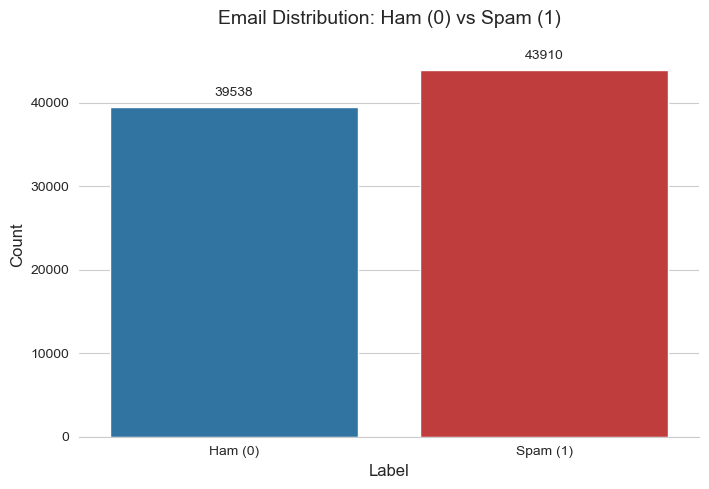

In [6]:
sns.set_style("whitegrid")

# Custom colors (ham = blue, spam = red)
palette = {'0': "#1f77b4", '1': "#d62728"}  # You can use any HEX/color names

# Create countplot
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='label', palette=palette)

# Add annotations (counts on top of bars)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points')

# Customize titles and labels
plt.title("Email Distribution: Ham (0) vs Spam (1)", fontsize=14, pad=20)
plt.xlabel("Label", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(ticks=[0, 1], labels=["Ham (0)", "Spam (1)"])

sns.despine(left=True)

plt.show()

### Word Cloud for Ham vs Spam

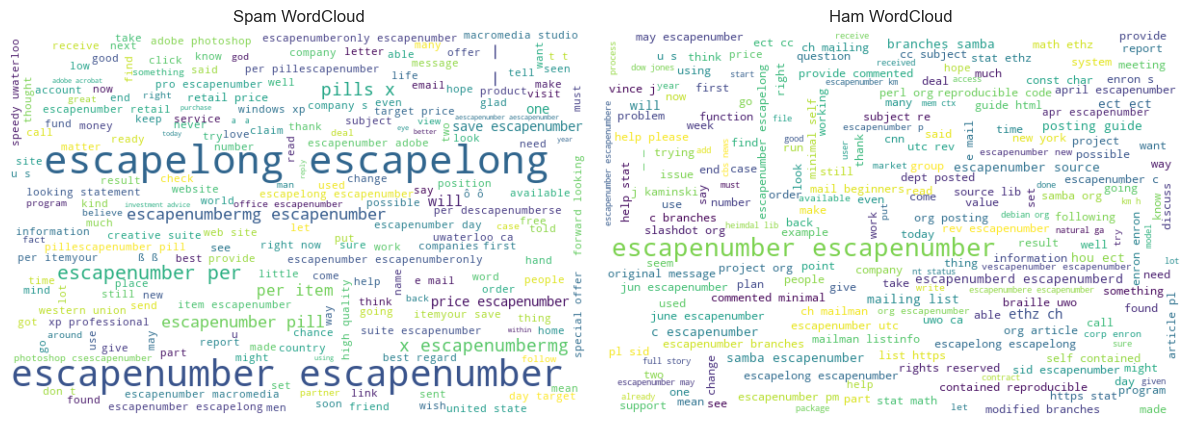

In [7]:
# Separate ham and spam texts
spam_words = " ".join(df[df['label'] == 1]['text'])
ham_words = " ".join(df[df['label'] == 0]['text'])

# Generate word clouds
spam_wc = WordCloud(width=600, height=400, background_color='white').generate(spam_words)
ham_wc = WordCloud(width=600, height=400, background_color='white').generate(ham_words)

# Plot
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(spam_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Spam WordCloud")

plt.subplot(1, 2, 2)
plt.imshow(ham_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Ham WordCloud")

plt.tight_layout()
plt.show()


### Text Length Distribution

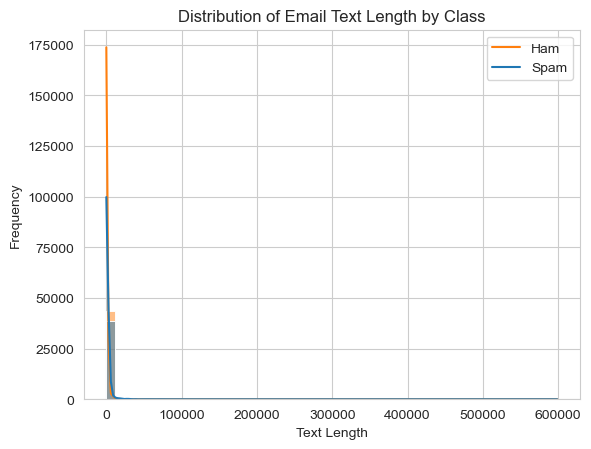

In [8]:
df['text_length'] = df['text'].apply(len)

sns.histplot(data=df, x='text_length', hue='label', bins=50, kde=True)
plt.title('Distribution of Email Text Length by Class')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.legend(['Ham', 'Spam'])
plt.show()

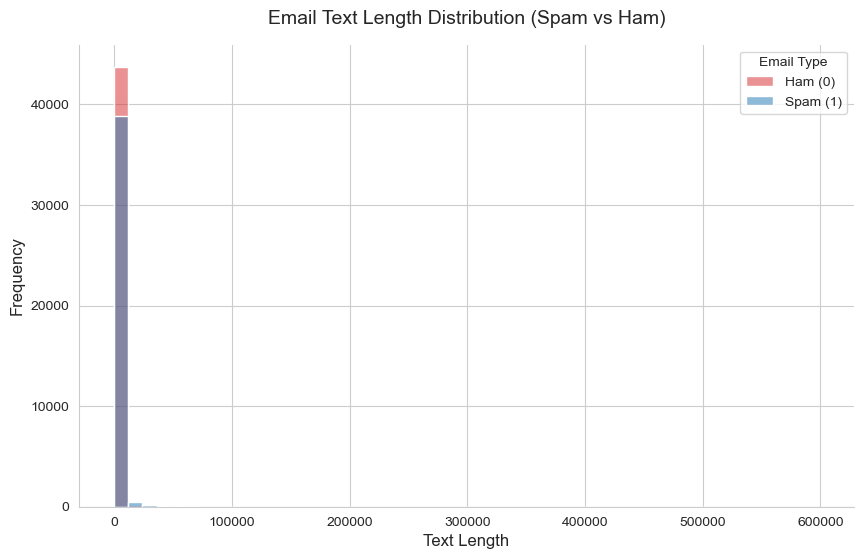

In [9]:
palette = {0: "#1f77b4", 1: "#d62728"}  # Blue for Ham, Red for Spam

# 2. Overlapping Histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='text_length', hue='label', bins=50, 
             palette=palette, alpha=0.5, hue_order=[0, 1])
plt.title("Email Text Length Distribution (Spam vs Ham)", fontsize=14, pad=15)
plt.xlabel("Text Length", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(title='Email Type', labels=['Ham (0)', 'Spam (1)'])
sns.despine()
plt.show()

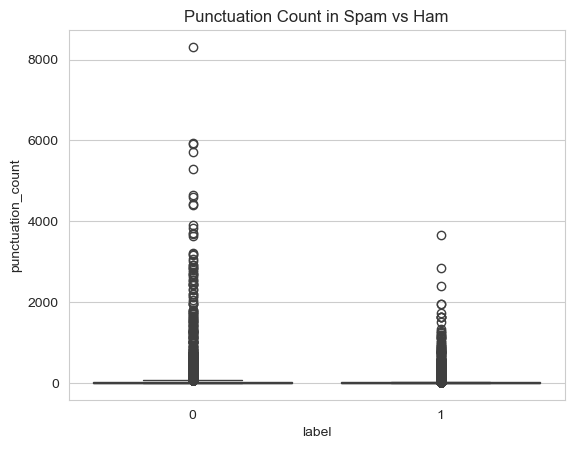

In [10]:
# check punctuation count
def count_punct(text):
    return sum(1 for char in text if char in string.punctuation)

df['punctuation_count'] = df['text'].apply(count_punct)

# Compare spam vs. ham
sns.boxplot(data=df, x='label', y='punctuation_count')
plt.title("Punctuation Count in Spam vs Ham")
plt.show()

### Top Words in Spam vs Ham

In [11]:
nltk.download('stopwords') # Download stopwords
# Initialize stop words
stop_words = set(stopwords.words('english'))

def get_top_words(texts, n=20): # Function to get top n words
    all_words = ' '.join(texts).lower()
    all_words = ''.join([c for c in all_words if c not in string.punctuation])
    words = all_words.split()
    words = [word for word in words if word not in stop_words]
    return Counter(words).most_common(n)

print("Top Spam Words:")
print(get_top_words(df[df['label'] == 1]['text']))

print("\nTop Ham Words:")
print(get_top_words(df[df['label'] == 0]['text']))



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\irdin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Top Spam Words:
[('escapenumber', 333218), ('escapelong', 188103), ('com', 29001), ('http', 27756), ('per', 26141), ('x', 23821), ('pills', 23128), ('escapenumbermg', 20541), ('price', 18723), ('company', 15870), ('one', 15858), ('save', 15005), ('may', 14662), ('item', 14473), ('e', 13893), ('us', 13822), ('time', 12354), ('please', 12332), ('get', 11989), ('new', 11401)]

Top Ham Words:
[('escapenumber', 799937), ('http', 54399), ('r', 53447), ('enron', 52856), ('c', 45218), ('org', 42557), ('com', 40681), ('escapelong', 39075), ('ect', 34743), ('help', 32661), ('samba', 30736), ('list', 28265), ('www', 28191), ('please', 26797), ('new', 25721), ('source', 25570), ('would', 25382), ('e', 22815), ('data', 22037), ('may', 21611)]


In [12]:
# 75% train, 25% test
X_train, X_test, y_train, y_test = train_test_split(df.text, df.label , test_size = 0.25) 

In [13]:
# Tfidf Vectorization

v = TfidfVectorizer(max_features=3000) 
X_train_tfidf = v.fit_transform(X_train.values)
X_train_tfidf[:5]


<5x3000 sparse matrix of type '<class 'numpy.float64'>'
	with 577 stored elements in Compressed Sparse Row format>

In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'Multinomial Naive Bayes': MultinomialNB()
}

In [15]:
from sklearn.metrics import accuracy_score

# Transform the test data using the same vectorizer
X_test_count = v.transform(X_test)

# Store results
results = {}

for name, model in models.items():
    # Train model
    model.fit(X_train_tfidf, y_train)

    # Predict on test data
    y_pred = model.predict(X_test_count)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

    print(f"{name} Accuracy: {accuracy:.4f}")
    print(f"{name} Classification Report:\n{classification_report(y_test, y_pred)}\n")


Logistic Regression Accuracy: 0.9806
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      9816
           1       0.98      0.99      0.98     11046

    accuracy                           0.98     20862
   macro avg       0.98      0.98      0.98     20862
weighted avg       0.98      0.98      0.98     20862


Random Forest Accuracy: 0.9850
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      9816
           1       0.98      0.99      0.99     11046

    accuracy                           0.98     20862
   macro avg       0.99      0.98      0.98     20862
weighted avg       0.99      0.98      0.98     20862


XGBoost Accuracy: 0.9825
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      9816
           1       0.98      0.

In [16]:
# Save the model 
joblib.dump(model, "spam_classifier_model.joblib")

# Save the vectorizer 
joblib.dump(v, "vectorizer.joblib")

['vectorizer.joblib']